In [1]:
import numpy as np
import astropy.units as u
import threading as th
import time 
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from importlib import reload
import copy
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoob_llowfsc
from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc import utils
from scoob_llowfsc import dm
from scoob_llowfsc import telem
import scoob_llowfsc.scoob_interface as scoobi
from scoob_llowfsc import iefc

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307


/opt/conda/envs/km310env/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Could not import deepdish!
Could not import ray. Parallelized model unavailble.


In [2]:
camsci_name = 'camlo'
camlo_name = 'camsci'
dm_lo_name = 'dm00disp02'
dm_ho_name = 'dm00disp03'

date = 20250416
data_path = scoob_llowfsc.path/'exp-data'
exp_path = data_path/f'exp-{date}'
iefc_data_path = data_path/f'exp-{today}'/'iefc'
iefc_telem_path = iefc_data_path/'raw-telem'
iefc_unpacked_path = iefc_data_path/'unpacked-telem'
llowfsc_data_path = data_path/f'exp-{today}'/'llowfsc'
llowfsc_telem_path = llowfsc_data_path/'raw-telem'
llowfsc_unpacked_path = llowfsc_data_path/'unpacked-telem'

camlo_ref_name = 'camlo_ref_0'
camlo_ref_offset_name = 'camlo_ref_offset'

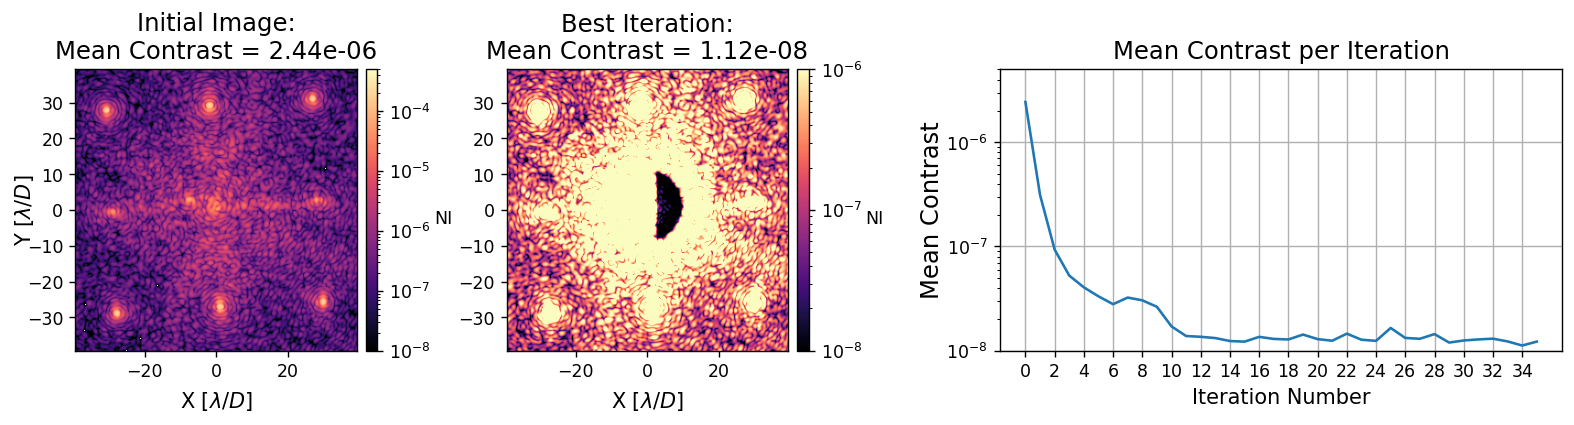

In [3]:
iefc_data = utils.load_pickle(iefc_data_path/'iefc_run_right.pkl')
control_mask = iefc_data['control_mask']

iefc.plot_data_with_ref(
    iefc_data,
    im1vmin=1e-8, im1vmax=5e-4,
    im2vmin=1e-8, im2vmax=1e-6, 
    vmin=1e-8, vmax=5e-6,
)

In [4]:
time_series_ims = xp.array([
    utils.load_fits(iefc_data_path/'camsci_ims_20250416122314.fits'),
    utils.load_fits(iefc_data_path/'camsci_ims_20250416125605.fits'),
    utils.load_fits(iefc_data_path/'camsci_ims_20250416132813.fits'),
    utils.load_fits(iefc_data_path/'camsci_ims_20250416140008.fits'),
])

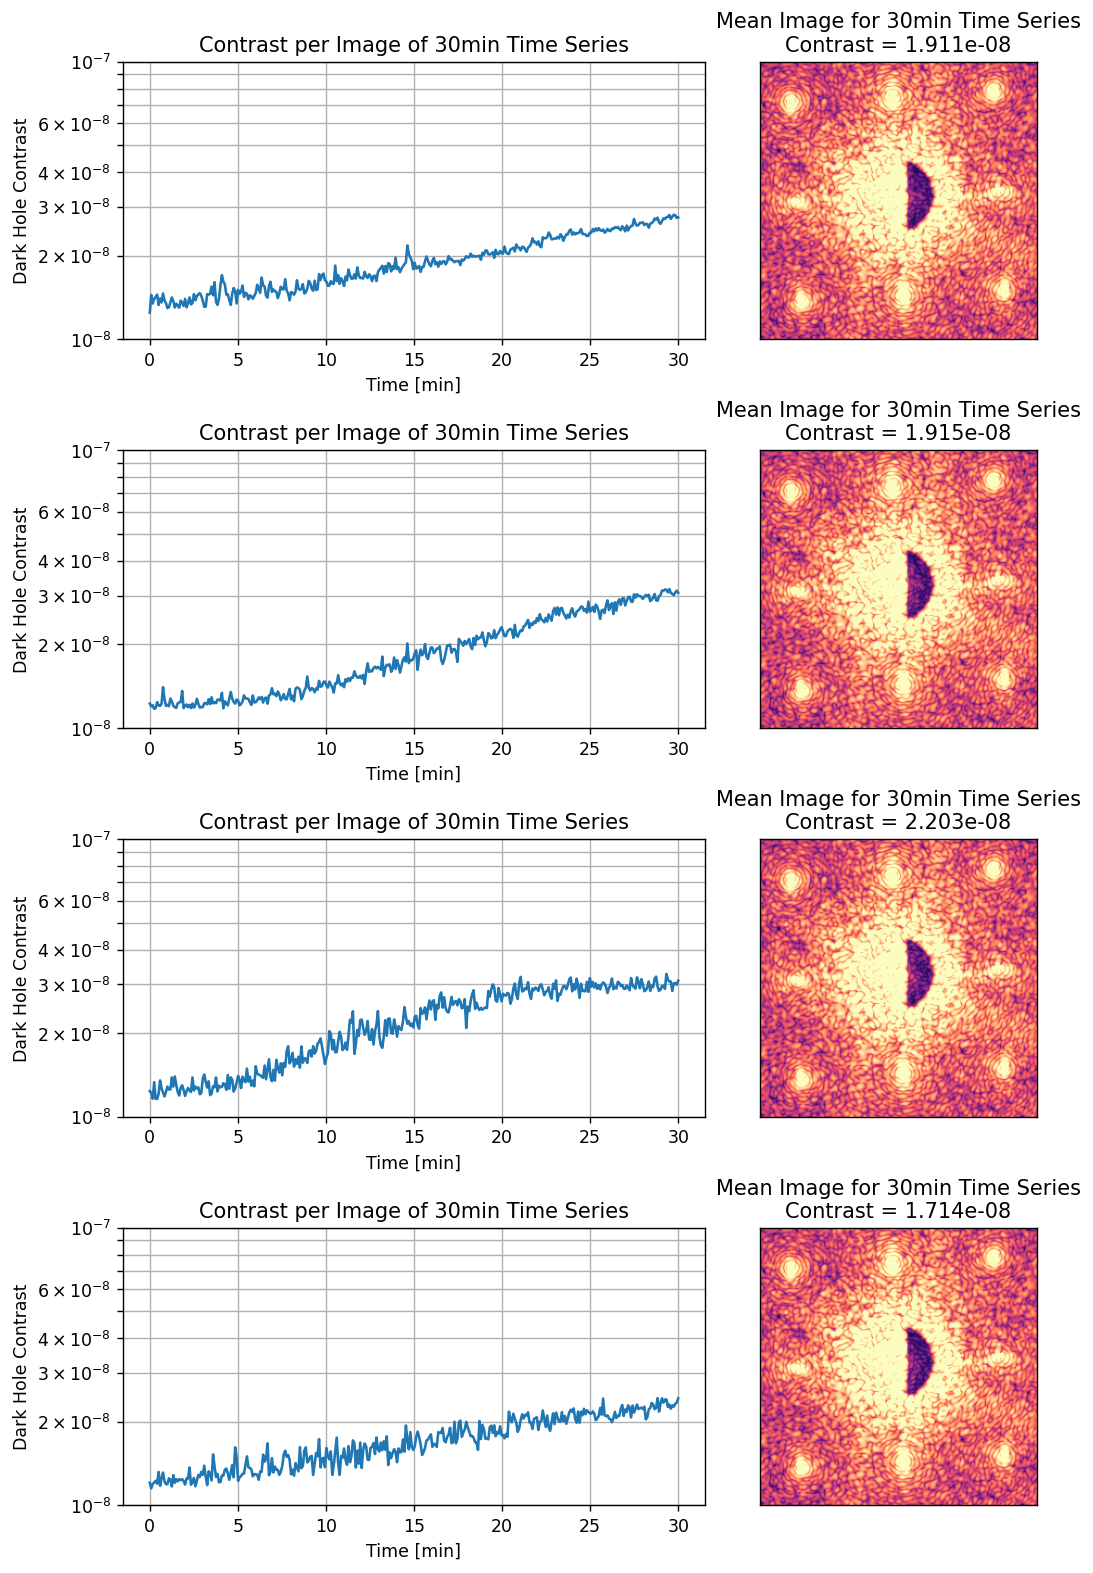

In [5]:
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(10,15), dpi=125, gridspec_kw={'width_ratios': [1.5, 1], })

time_steps = np.linspace(0, 30, time_series_ims.shape[1])
time_ticks = np.arange(0, 30.01, 5)

mean_im_per_series = []
mean_contrasts = []
for i in range(time_series_ims.shape[0]):
    series_ims = time_series_ims[i]
    mean_im = xp.mean(series_ims, axis=0)
    mean_im_per_series.append(mean_im)
    mean_contrasts.append(xp.mean(mean_im[control_mask]))
    series_contrasts = xp.mean(time_series_ims[i, :, control_mask], axis=0)
    
    ax1 = axs[i,0]
    ax1.semilogy(time_steps, ensure_np_array(series_contrasts))
    ax1.set_title(f'Contrast per Image of 30min Time Series')
    ax1.set_xlabel('Time [min]')
    ax1.set_ylabel('Dark Hole Contrast')
    ax1.set_ylim(1e-8, 1e-7)
    ax1.set_yticks(np.linspace(1e-8,1e-7,10))
    ax1.set_xticks(time_ticks)
    ax1.grid()
    # ax1.set_xlim()

    ax2 = axs[i,1]
    ax2.imshow(ensure_np_array(mean_im_per_series[i]), norm=LogNorm(1e-9), cmap='magma')
    ax2.set_title(f'Mean Image for 30min Time Series\nContrast = {mean_contrasts[i]:.3e}')
    ax2.set_xticks([])
    ax2.set_yticks([])

plt.subplots_adjust(
    wspace=0.0, 
    hspace=0.4,
)

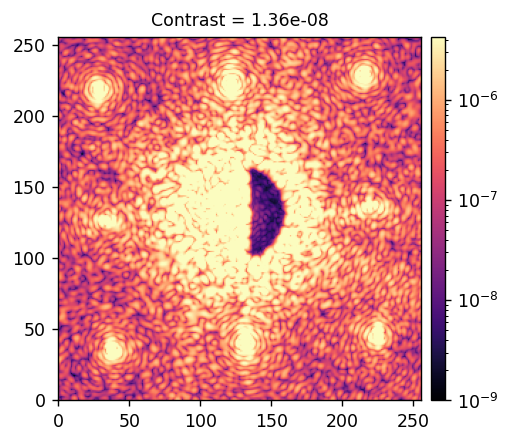

In [6]:
start_times = [
    '20250416143235',
    '20250416144338',
    '20250416145431',
    '20250416150533',
    '20250416151617',
    '20250416152706',
]

series_start = start_times[0]
time_series_ims = []
for i in range(len(start_times)):
    time_series_ims.append( utils.load_fits(iefc_data_path/f'camsci_ims_{start_times[i]}.fits') ) 
time_series_ims = xp.array(time_series_ims)

mean_im = xp.mean(time_series_ims, axis=(0, 1))
mean_contrast = xp.mean(mean_im[control_mask])

utils.imshow(
    [mean_im],
    titles=[f'Contrast = {mean_contrast:.2e}'],
    norms=[LogNorm(1e-9)],
)


In [7]:
series_times = []
series_start_times = []
series_contrasts = []

for i in range(len(start_times)):
    t_hr = float(start_times[i][-6:-4])
    t_min = float(start_times[i][-4:-2])
    t_sec = float(start_times[i][-2:])
    series_start_times.append( 3600*t_hr + 60*t_min + t_sec ) 
    # print(t_hr, t_min, t_sec)
    print(series_start_times[i])
    # series_times.append(  )
    series_contrasts.append( xp.mean(time_series_ims[i, :, control_mask], axis=0) )

series_start_times = np.array( series_start_times )
series_start_times -= series_start_times[0]
print(series_start_times/60)
series_contrasts = xp.array(series_contrasts)

52355.0
53018.0
53671.0
54333.0
54977.0
55626.0
[ 0.         11.05       21.93333333 32.96666667 43.7        54.51666667]


In [32]:
series_contrasts[0].shape

(120,)

[]

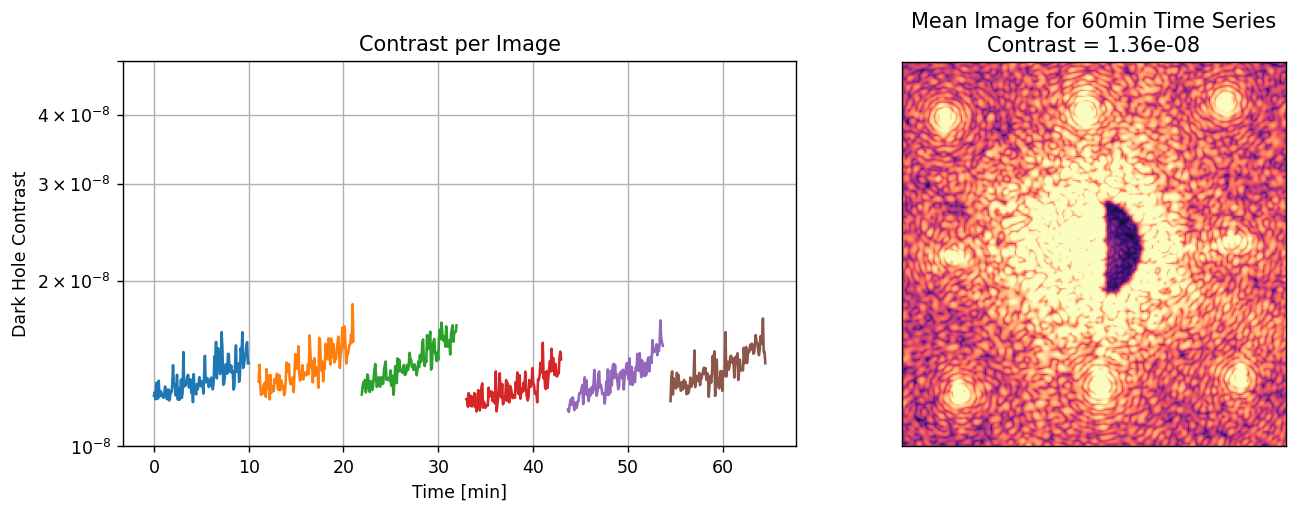

In [8]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,4), dpi=125, gridspec_kw={'width_ratios': [1.75, 1], })

vmin = 1e-8
vmax = 5e-8

time_steps = np.linspace(0, 10, time_series_ims.shape[1])
for i in range(len(start_times)):
    axs[0].semilogy(time_steps + series_start_times[i]/60, ensure_np_array(series_contrasts[i]))
axs[0].set_ylim(vmin, vmax)
axs[0].set_yticks(np.linspace(vmin, vmax, 5))
axs[0].set_ylabel('Dark Hole Contrast')
axs[0].set_xlabel('Time [min]')
axs[0].grid()
axs[0].set_title('Contrast per Image')

axs[1].imshow(ensure_np_array(mean_im), norm=LogNorm(1e-9), cmap='magma')
axs[1].set_title(f'Mean Image for 60min Time Series\nContrast = {mean_contrast:.2e}')
axs[1].set_xticks([])
axs[1].set_yticks([])